# 01 — Eksplorasi Data

Notebook ini menampilkan statistik dataset hasil ekstraksi & chunking dari 4 UU.
Cocok untuk slide *Dataset* pada presentasi.

**Prasyarat:** sudah menjalankan `python scripts/01_extract.py` dan `python scripts/02_chunk.py`.

In [2]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent))  # agar bisa import src

import pandas as pd
from src.config import load_config, resolve_path

cfg = load_config()
chunks_path = resolve_path(cfg['paths']['processed_dir']) / 'chunks.jsonl'
rows = [json.loads(l) for l in open(chunks_path, encoding='utf-8')]
df = pd.json_normalize(rows)
print('Total chunk:', len(df))
df.head()

Total chunk: 859


,id,domain,text,metadata.pasal,metadata.bab,metadata.part
0,KETENAGAKERJAAN_PASAL_1,ketenagakerjaan,Pasal 1 Dalam undang undang ini yang dimaksud ...,1,BAB I,0
1,KETENAGAKERJAAN_PASAL_1_p1,ketenagakerjaan,tertentu mengenai ketenagakerjaan. 9. Pelatiha...,1,BAB I,1
2,KETENAGAKERJAAN_PASAL_1_p2,ketenagakerjaan,"di perusahaan maupun di luar perusahaan, yang ...",1,BAB I,2
3,KETENAGAKERJAAN_PASAL_1_p3,ketenagakerjaan,hal tertentu yang mengakibatkan berakhirnya ha...,1,BAB I,3
4,KETENAGAKERJAAN_PASAL_2,ketenagakerjaan,Pasal 2 Pembangunan ketenagakerjaan berlandask...,2,BAB II,0


## Jumlah chunk per domain

domain
ketenagakerjaan    426
anak               208
konsumen           141
ite                 84
Name: count, dtype: int64


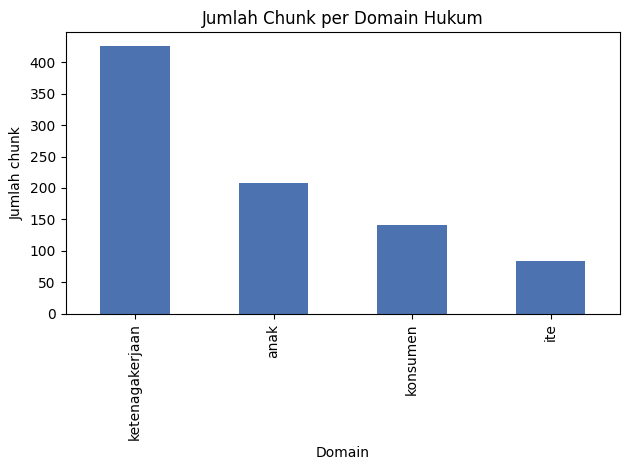

In [3]:
import matplotlib.pyplot as plt

per_domain = df['domain'].value_counts()
print(per_domain)
ax = per_domain.plot(kind='bar', color='#4C72B0', title='Jumlah Chunk per Domain Hukum')
ax.set_xlabel('Domain'); ax.set_ylabel('Jumlah chunk')
plt.tight_layout(); plt.show()

## Distribusi panjang chunk (jumlah kata)

count    859.000000
mean      51.176950
std       61.633808
min        1.000000
25%        7.000000
50%       29.000000
75%       66.500000
max      256.000000
Name: n_kata, dtype: float64


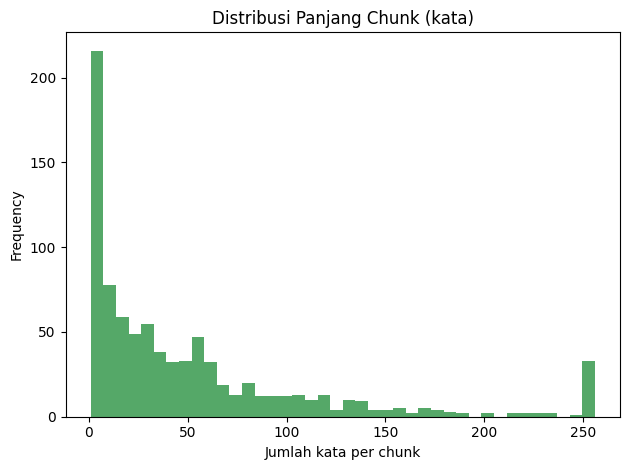

In [4]:
df['n_kata'] = df['text'].str.split().str.len()
print(df['n_kata'].describe())
df['n_kata'].plot(kind='hist', bins=40, color='#55A868', title='Distribusi Panjang Chunk (kata)')
plt.xlabel('Jumlah kata per chunk'); plt.tight_layout(); plt.show()

## Contoh chunk (satu pasal)

In [5]:
contoh = df[df['domain'] == 'ketenagakerjaan'].iloc[10]
print('ID   :', contoh['id'])
print('BAB  :', contoh['metadata.bab'])
print('Pasal:', contoh['metadata.pasal'])
print('-'*70)
print(contoh['text'][:600])

ID   : KETENAGAKERJAAN_PASAL_8
BAB  : BAB IV
Pasal: 8
----------------------------------------------------------------------
Pasal 8 1. Perencanaan tenaga kerja disusun atas dasar informasi ketenagakerjaan yang antara lain meliputi : a. penduduk dan tenaga kerja; b. kesempatan kerja; c. pelatihan kerja termasuk kompetensi kerja; d. produktivitas tenaga kerja; e. hubungan industrial; f. kondisi lingkungan kerja; g. pengupahan dan kesejahteraan tenaga kerja; h. jaminan sosial tenaga kerja. (2) Informasi ketenagakerjaan sebagaimana dimaksud dalam ayat (1), diperoleh dari semua pihak yang terkait, baik instansi pemerintah maupun swasta. (3) Ketentuan mengenai tata cara memperoleh informasi ketenagakerjaan dan penyusunan
